# Assignment 1, Task A: Classification problem.

## The data:
In this QSAR exercise, the mutagenicity of various molecules is to be investigated. The dataset in use is the Ames Mutagenicity Dataset for Multi-Task learning accessed via the PyTDC library, essentially as also provided here: https://huggingface.co/datasets/scikit-fingerprints/TDC_ames. Columns have been renamed for enhanced clarity.

The dataset gives the overal mutagenicity (1 = mutagen) of various drugs (simply represented as their SMILES string). From the SMILES strings, molecular fingerprints can be generated as molecular descriptors.

## The tasks:
1) Inspect the data and clean if needed. Adhere to good practices!
2) Calculate the fingerprints (partial snippet provided) and create a feature matrix X and a target vector y
3) Then four different models should be trained on the fingerprints and evaluated according to accuracy and their roc-auc score to compare their performance. For each model, additionally, the overfitting needs to be addressed.

These four models have to be compared:
- `KNeighborsClassifier`: choose a suitable number of neighbors
- `DecisionTreeClassifier`: use a random_state
- `RandomForestClassifier`: use a random_state and a slightly bigger forest (e.g. 200 trees)
- `GradientBoostingClassifier`: use a random_state

Other than the stated parameters, the models can be mostly used as provided by `scikit`. No hyperparameter tuning needs to be performed, no CV necessary.

4) Conclusion and discussion: Provide answers to the questions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("ames_data.csv")
df.head()

,drug_id,smiles,mutagenicity
0,Drug 0,O=[N+]([O-])c1ccc2ccc3ccc([N+](=O)[O-])c4c5ccc...,1
1,Drug 1,O=[N+]([O-])c1c2c(c3ccc4cccc5ccc1c3c45)CCCC2,1
2,Drug 2,O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...,0
3,Drug 3,[N-]=[N+]=CC(=O)NCC(=O)NN,1
4,Drug 4,[N-]=[N+]=C1C=NC(=O)NC1=O,1


## 1. Inspect and clean the data
- Gain some overview of the data and assess NaNs and duplicates and clean if needed.
- Inspect the class balance!

In [ ]:
# Genral information on the data
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7278 entries, 0 to 7277
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   drug_id       7278 non-null   object
 1   smiles        7278 non-null   object
 2   mutagenicity  7278 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 170.7+ KB


,mutagenicity
count,7278.000000
mean,0.546029
std,0.497911
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# Checking for NaNs
df.isna().sum()

drug_id         0
smiles          0
mutagenicity    0
dtype: int64

In [20]:
# Inspecting and visualiting the class balance in the column mutagenicity
df["mutagenicity"].value_counts()

mutagenicity
1    3974
0    3304
Name: count, dtype: int64

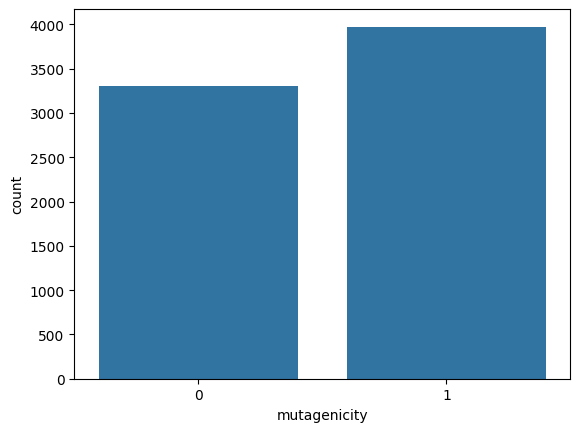

In [21]:
sns.countplot(data=df, x="mutagenicity")
plt.show()

## 2. Create fingerprints from the Smiles
The partial snippet for MorganFingerprints can be used. Note that instead of a dataframe, the function will produce a np.array, which will be written into a list. From this you can create the feature matrix and the target vector. Inspect the shape of the arrays!

In [22]:
def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    fp = mfpgen.GetFingerprint(mol)
    return np.array(fp)

# Convert to fingerprints
fps = []
valid_labels = []

for smiles, label in zip(df["smiles"], df["mutagenicity"]):
    fp = smiles_to_fp(smiles)
    if fp is not None:
        fps.append(fp)
        valid_labels.append(label)


In [ ]:
# Turning fps and valid_labels into arrays (X = features, y = target)
X = np.array(fps)
y = np.array(valid_labels)

In [29]:
# inspecting arrays
print(f"X array shape: {X.shape}")
print(f"y array shape: {y.shape}")

X array shape: (7278, 2048)
y array shape: (7278,)


## 3. Train the models
Use a classic train-test split of 0.2 including a random seed and `stratify`. For training and predicting labels, take note of the time the process takes for each model (does not necessarily have to be coded, can also be estimated). Make sure to predict labels for both training and test splits in order to identify overfitting. Use the accuracy and roc-auc as metrics for evaluation.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% test set
    random_state=42,     # reproducibility
    stratify=y
)

In [79]:
# KNN
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder

k = 5

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=k))
])

pipe.fit(X_train, y_train)

y_pred_test_KNN = pipe.predict(X_test)
y_proba_test_KNN = pipe.predict_proba(X_test)[:, 1] #proba means probability

y_pred_train_KNN = pipe.predict(X_train)
y_proba_train_KNN = pipe.predict_proba(X_train)[:, 1] #proba means probability

In [80]:
# Decision Tree

dt_default = DecisionTreeClassifier(random_state=42)

dt_default.fit(X_train, y_train)

y_pred_train_DT = dt_default.predict(X_train)
y_proba_train_DT = dt_default.predict_proba(X_train)[:, 1]

y_pred_test_DT = dt_default.predict(X_test)
y_proba_test_DT = dt_default.predict_proba(X_test)[:, 1]

In [81]:
# Random Forest

rf_default = RandomForestClassifier(random_state=42, n_estimators=200) #changing trees to 200

rf_default.fit(X_train, y_train)

y_pred_test_RF = rf_default.predict(X_test) 
y_proba_test_RF = rf_default.predict_proba(X_test)[:, 1]

y_pred_train_RF = rf_default.predict(X_train) 
y_proba_train_RF = rf_default.predict_proba(X_train)[:, 1] 

In [84]:
# Gradient Boosting

gb_default = GradientBoostingClassifier(random_state=42)

gb_default.fit(X_train, y_train)

y_pred_test_GB = gb_default.predict(X_test)
y_proba_test_GB = gb_default.predict_proba(X_test)[:, 1] 

y_pred_train_GB = gb_default.predict(X_train)
y_proba_train_GB = gb_default.predict_proba(X_train)[:, 1] 

In [85]:
# Printing results from all four models

print("KNN:")
print("Train Accuracy:", accuracy_score(y_train, y_pred_train_KNN))
print("Train ROC-AUC:", roc_auc_score(y_train, y_proba_train_KNN))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test_KNN))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_test_KNN))
print("------------------------------------------------")
print("Decision Tree:")
print("Train Accuracy:", accuracy_score(y_train, y_pred_train_DT))
print("Train ROC-AUC:", roc_auc_score(y_train, y_proba_train_DT))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test_DT))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_test_DT))
print("------------------------------------------------")
print("Random Forest:")
print("Train Accuracy:", accuracy_score(y_train, y_pred_train_RF))
print("Train ROC-AUC:", roc_auc_score(y_train, y_proba_train_RF))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test_RF))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_test_RF))
print("------------------------------------------------")
print("Gradient Boosting:")
print("Train Accuracy:", accuracy_score(y_train, y_pred_train_GB))
print("Train ROC-AUC:", roc_auc_score(y_train, y_proba_train_GB))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test_GB))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_test_GB))

KNN:
Train Accuracy: 0.8503950532463072
Train ROC-AUC: 0.9246505366457922
Test Accuracy: 0.7184065934065934
Test ROC-AUC: 0.7984338576009287
------------------------------------------------
Decision Tree:
Train Accuracy: 0.9994847131569907
Train ROC-AUC: 0.9999994644194181
Test Accuracy: 0.7767857142857143
Test ROC-AUC: 0.7720749008078098
------------------------------------------------
Random Forest:
Train Accuracy: 0.9994847131569907
Train ROC-AUC: 0.9999994644194181
Test Accuracy: 0.8248626373626373
Test ROC-AUC: 0.9008249364884539
------------------------------------------------
Gradient Boosting:
Train Accuracy: 0.8096873926485744
Train ROC-AUC: 0.8946958122478234
Test Accuracy: 0.7726648351648352
Test ROC-AUC: 0.8511222751881559


## 4. Conclusion and discussion
- Which model performed the best?

Based on the results, random forest performed the best with the higest test accuracy and a high ROC value.
- Which was the most time efficient?

KNN.
- Which model showed the worst overfitting?

Can see overfitting when comparing training performance to test performance. Decision Tree showed the worst overfitting.
- Why does ensemble learning outperform a single tree?

Because it combines the prediction of multiple trees, which reduces overfitting as seen with Decision Tree. A single tree is not very robust and can be very sensitive.
- Why does KNN perform well in high-dimensional fingerprint space?

KNN did not perform well. I think KNN does not really work that well in high dimensional spaces. (WRONG)
- What does ROC-AUC tell us that accuracy does not?

ROC tells us how well the model can seprate the two groups, in this case mutagenicity. Accuracy only gives information about the correct predictions.